In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit


In [3]:
# Paramètres
J = 1.0  # interaction entre spins
kB = 1.0  # constante de Boltzmann


In [4]:
# Initialisation du réseau : fonction qui créé un réseau LxL avec des spins aléatoires (-1 ou +1)."""
def initialise(L):
    return np.random.choice([-1, 1], size=(L, L))


In [5]:
# Fonction qui calcul la variation d'énergie associée au retournement d'un spin 

@njit
def delta_energie(spins, i, j, h):
    L = spins.shape[0]
    S = spins[i, j]
    v = (
        spins[(i+1)%L, j] + spins[(i-1)%L, j] +
        spins[i, (j+1)%L] + spins[i, (j-1)%L]
    )
    return 2* S * (J * v + h)


In [6]:
# Fonction qui fait un pas de Monte - Carlo (retournement de N spins)
@njit
def metropolis_pas(spins, T, h):
    L = spins.shape[0]

    for k in range(L * L):
    # On se donne un spin aléatoire i,j dans la configuration.
        i = np.random.randint(0, L)
        j = np.random.randint(0, L)

    # Appel de la fonction delta_energie

        dE = delta_energie(spins, i, j, h)

    # Condition de retournement


        if dE <= 0 or np.random.rand() < np.exp(-dE / T):
            spins[i, j] *= -1

In [7]:
#Fonction qui calcule l'aimantation (moyenne des spins)
@njit
def aimantation(spins):
    return np.mean(spins)


In [8]:
#Fonction qui calcule l'énergie totale du système
@njit
def energie(spins, h):
    L = spins.shape[0]
    E = 0.0
    for i in range(L):
        for j in range(L):
            S = spins[i, j]
            voisins = spins[(i+1)%L, j] + spins[i, (j+1)%L]
            E += -J * S * voisins - h * S
    return E  

In [9]:
#Simulation : on fixe la température T et on regarde l'évolution des grandeurs en fonction du nombre de pas de Monte - Carlo

def simulation(L, T, n_max=10000):
    #On fixe une configuration aléatoire
    spins = initialise(L)

    #Initialisation des listes
    M_list = []
    chi_list = []
    C_list = []
    E_list = []


    for pas in range(n_max):
        #Un pas de Monte-Carlo
        metropolis_pas(spins, T, h=0.0)

        #Aimantation
        M = aimantation(spins)
        M_list.append(abs(M))
        
        #Energie totale
        E = energie(spins, h=0.0)
        E_list.append(E)

        # Susceptibilité χ = variance(M) / T 
        chi = np.var(M_list) / T
        chi_list.append(chi)

        # Chaleur spécifique C = variance(E) / T^2 
        C = np.var(E_list) / T**2
        C_list.append(C)


    return M_list, chi_list, C_list, E_list


Simulation à T = 1.800 K
Simulation à T = 2.200 K
Simulation à T = 2.269 K
Simulation à T = 2.700 K
Simulation à T = 4.000 K


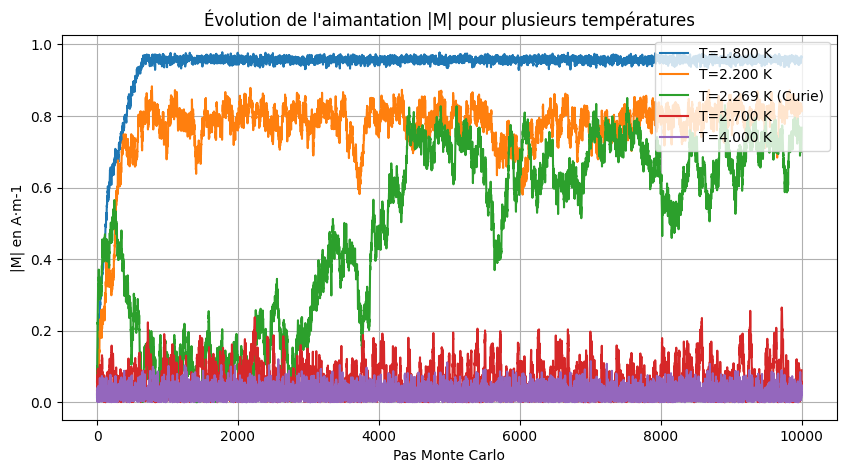

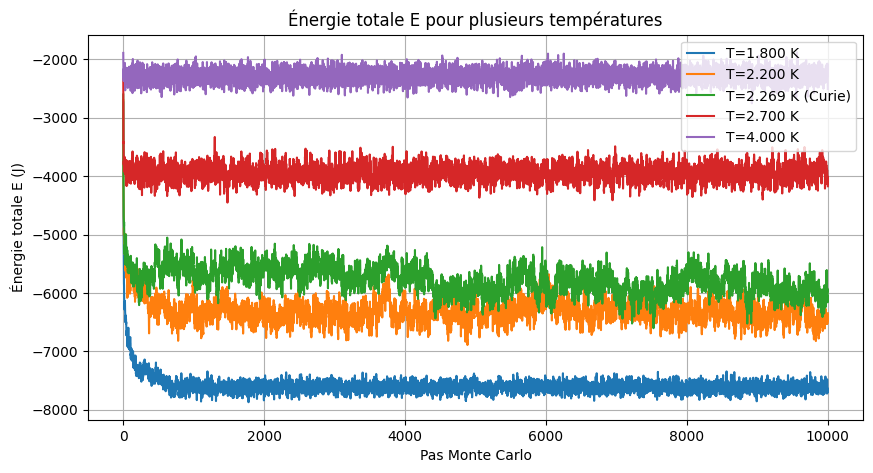

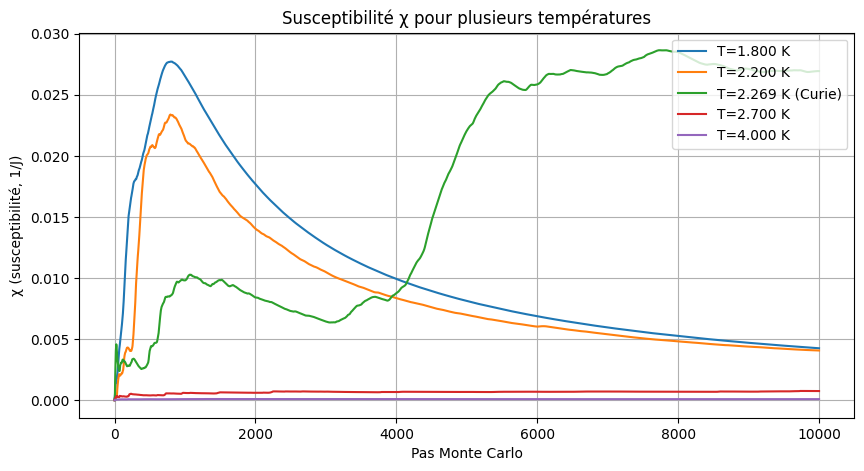

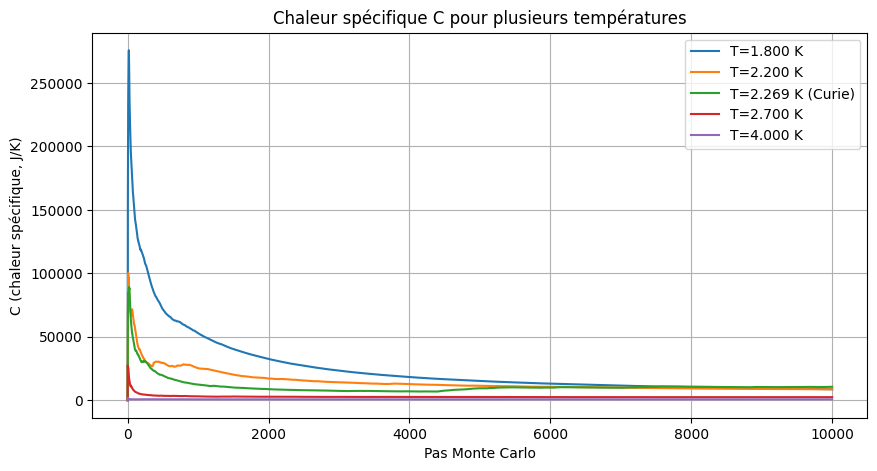

In [12]:
#Programme principal
np.random.seed(0)


L = 64  # taille du réseau

#Températures
Tlist = [1.8, 2.2, 2.269, 2.7, 4.0]


# Listes des grandeurs pour toutes les températures
M_all = []
E_all = []
chi_all = []
C_all = []


for T in Tlist:
    print(f"Simulation à T = {T:.3f} K")
    M_list, chi_list, C_list, E_list = simulation(L, T)
    M_all.append(M_list)
    E_all.append(E_list)
    chi_all.append(chi_list)
    C_all.append(C_list)


#Aimantation en fonction du nombre de pas de Monte - Carlo pour différentes températures
plt.figure(figsize=(10,5))
for i, T in enumerate(Tlist):
    label = f"T={T:.3f} K"
    if np.isclose(T, 2.269):  # marque la température de Curie
        label += " (Curie)"
    plt.plot(M_all[i], label=label)
plt.xlabel("Pas Monte Carlo")
plt.ylabel("|M| en A·m-1")
plt.title("Évolution de l'aimantation |M| pour plusieurs températures")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()


#Energie en fonction du nombre de pas de Monte - Carlo pour différentes températures
plt.figure(figsize=(10,5))
for i, T in enumerate(Tlist):
    label = f"T={T:.3f} K"
    if np.isclose(T, 2.269):
        label += " (Curie)"
    plt.plot(E_all[i], label=label)
plt.xlabel("Pas Monte Carlo")
plt.ylabel("Énergie totale E (J)")
plt.title("Énergie totale E pour plusieurs températures")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()


#Susceptibilité en fonction du nombre de pas de Monte - Carlo pour différentes températures
plt.figure(figsize=(10,5))
for i, T in enumerate(Tlist):
    label = f"T={T:.3f} K"
    if np.isclose(T, 2.269):
        label += " (Curie)"
    plt.plot(chi_all[i], label=label)
plt.xlabel("Pas Monte Carlo")
plt.ylabel("χ (susceptibilité, 1/J)")
plt.title("Susceptibilité χ pour plusieurs températures")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()


#Chaleur spécifique en fonction du nombre de pas de Monte - Carlo pour différentes températures
plt.figure(figsize=(10,5))
for i, T in enumerate(Tlist):
    label = f"T={T:.3f} K"
    if np.isclose(T, 2.269):
        label += " (Curie)"
    plt.plot(C_all[i], label=label)
plt.xlabel("Pas Monte Carlo")
plt.ylabel("C (chaleur spécifique, J/K)")
plt.title("Chaleur spécifique C pour plusieurs températures")
plt.legend(loc = "upper right")
plt.grid(True)
plt.show()


